# CGCNN + Temperature dự đoán TC

Notebook này giữ pipeline đơn giản giống CGCNN mẫu:

`CIF -> crystal graph -> CGCNN -> graph embedding + temperature -> TC`

- Input: graph từ CIF + `Temperature (K)`.
- Output: `TC`.

In [1]:
# !unzip MP_CIF_files.zip

In [2]:
# Cell 1 - Cài thư viện nếu chạy trên Colab
import sys, subprocess, importlib.util

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

if importlib.util.find_spec("ase") is None:
    pip_install("ase")

if importlib.util.find_spec("torch_geometric") is None:
    pip_install("torch-geometric")

print("Done")

Done


In [3]:
# Cell 2 - Import
import os
import re
import glob
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from ase.io import read
from ase.neighborlist import neighbor_list

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Cell 3 - Đọc dữ liệu
CSV_PATH = r"C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\mp_cif_matched_data_TE.csv"

df = pd.read_csv(CSV_PATH)

print("CSV_PATH:", CSV_PATH)
print("Shape:", df.shape)
print(df.columns.tolist())
display(df.head())

CSV_PATH: C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\mp_cif_matched_data_TE.csv
Shape: (707, 10)
['identifier', 'formula', 'atoms', 'num_atoms', 'Formula_original', 'Temperature (K)', 'TC', 'DOI', 'formation_energy_per_atom', 'cif_path']


,identifier,formula,atoms,num_atoms,Formula_original,Temperature (K),TC,DOI,formation_energy_per_atom,cif_path
0,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,295.0,1.03,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
1,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,346.0,0.89,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
2,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,400.0,0.78,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
3,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,449.0,0.72,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif
4,mp-691,SnSe,"MSONAtoms(symbols='Sn4Se4', pbc=True, cell=[4....",2,Sn50Se50,500.0,0.67,10.1039/C4TA01643B?urlappend=%3Futm_source%3D...,-0.453546,downloaded_cif_TE\mp-691_SnSe.cif


In [5]:
# Cell 4 - Làm sạch dữ liệu
required_cols = ["identifier", "formula", "Temperature (K)", "TC", "cif_path"]
missing_cols = [c for c in required_cols if c not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Thiếu cột: {missing_cols}")

df = df.dropna(subset=["identifier", "formula", "Temperature (K)", "TC", "cif_path"]).copy()
df["Temperature (K)"] = pd.to_numeric(df["Temperature (K)"], errors="coerce")
df["TC"] = pd.to_numeric(df["TC"], errors="coerce")
df = df.dropna(subset=["Temperature (K)", "TC"]).reset_index(drop=True)

print("After cleaning:", df.shape)
display(df[["identifier", "formula", "Temperature (K)", "TC", "cif_path"]].head())

After cleaning: (707, 10)


,identifier,formula,Temperature (K),TC,cif_path
0,mp-691,SnSe,295.0,1.03,downloaded_cif_TE\mp-691_SnSe.cif
1,mp-691,SnSe,346.0,0.89,downloaded_cif_TE\mp-691_SnSe.cif
2,mp-691,SnSe,400.0,0.78,downloaded_cif_TE\mp-691_SnSe.cif
3,mp-691,SnSe,449.0,0.72,downloaded_cif_TE\mp-691_SnSe.cif
4,mp-691,SnSe,500.0,0.67,downloaded_cif_TE\mp-691_SnSe.cif


Number of rows: 707
Number of unique mp-id: 43
Number of unique formula: 43


,Temperature (K),TC
count,707.000000,707.000000
mean,461.818027,2.616016
std,212.021098,3.301871
min,5.000000,0.220000
25%,323.000000,0.695000
50%,448.364000,1.180000
75%,617.210500,3.221175
max,1176.092000,30.450000


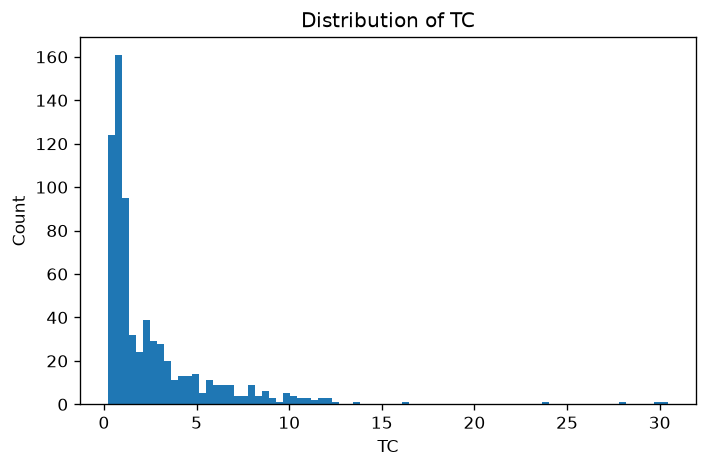

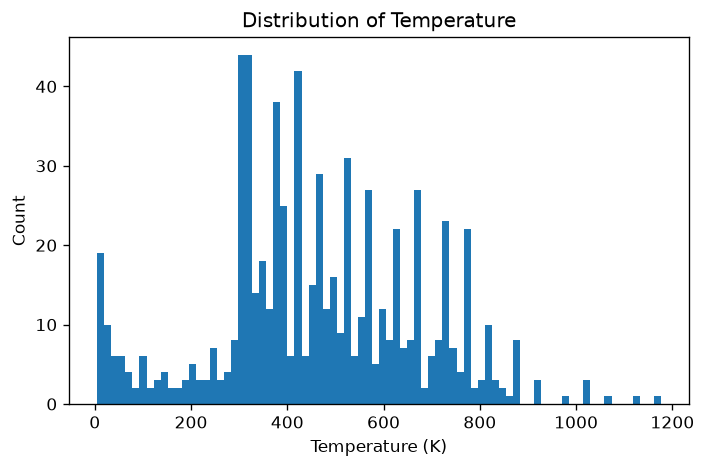

In [6]:
# Cell 5 - Thống kê dữ liệu
print("Number of rows:", len(df))
print("Number of unique mp-id:", df["identifier"].nunique())
print("Number of unique formula:", df["formula"].nunique())

display(df[["Temperature (K)", "TC"]].describe())

plt.figure(figsize=(6,4), dpi=120)
plt.hist(df["TC"], bins=80)
plt.xlabel("TC")
plt.ylabel("Count")
plt.title("Distribution of TC")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4), dpi=120)
plt.hist(df["Temperature (K)"], bins=80)
plt.xlabel("Temperature (K)")
plt.ylabel("Count")
plt.title("Distribution of Temperature")
plt.tight_layout()
plt.show()

In [7]:
# Cell 6 - Tìm đúng file CIF trong folder MP_CIF_files
# Folder của bạn trong Colab: /content/MP_CIF_files
CIF_FOLDER = r"C:\Users\Admin\Downloads\TC alloys and TE CGCNN prediction\thermoelectric\final_CGCNN_GNN_model_for_TE_TC\downloaded_cif_TE"

all_cif_files = glob.glob(os.path.join(CIF_FOLDER, "*.cif"))
mpid_to_cif = {}

for f in all_cif_files:
    name = os.path.basename(f)
    m = re.search(r"mp-\d+", name)
    if m:
        mpid_to_cif[m.group()] = f

print("Số file CIF trong folder:", len(all_cif_files))
print("Số mp-id tìm được trong folder:", len(mpid_to_cif))


def resolve_cif_path(row):
    identifier = str(row["identifier"]).strip()
    cif_path = str(row["cif_path"]).strip()

    # 1. Nếu đường dẫn gốc tồn tại
    candidates = [
        cif_path,
        os.path.join(os.path.dirname(CSV_PATH), cif_path),
        os.path.join("/content", cif_path),
        os.path.join(CIF_FOLDER, os.path.basename(cif_path)),
    ]

    for p in candidates:
        if os.path.exists(p):
            return p

    # 2. Match theo mp-id, không phụ thuộc formula trong tên file
    m = re.search(r"mp-\d+", identifier)
    if m and m.group() in mpid_to_cif:
        return mpid_to_cif[m.group()]

    m = re.search(r"mp-\d+", cif_path)
    if m and m.group() in mpid_to_cif:
        return mpid_to_cif[m.group()]

    return None


df["resolved_cif_path"] = df.apply(resolve_cif_path, axis=1)

n_missing = df["resolved_cif_path"].isna().sum()
print("Total rows:", len(df))
print("Rows with existing CIF:", len(df) - n_missing)
print("Rows missing CIF:", n_missing)

if n_missing > 0:
    missing_unique = df[df["resolved_cif_path"].isna()][["identifier", "formula", "cif_path"]].drop_duplicates()
    print("Missing unique CIF:", len(missing_unique))
    display(missing_unique.head(30))

Số file CIF trong folder: 43
Số mp-id tìm được trong folder: 43
Total rows: 707
Rows with existing CIF: 707
Rows missing CIF: 0


In [8]:
# Cell 7 - Chỉ giữ các dòng có CIF tồn tại
# Không có CIF thì không thể tạo crystal graph.
df = df[df["resolved_cif_path"].notna()].reset_index(drop=True)

print("Data used for CGCNN:", df.shape)
print("Unique CIF used:", df["identifier"].nunique())

display(df[["identifier", "formula", "Temperature (K)", "TC", "resolved_cif_path"]].head())

if len(df) == 0:
    raise ValueError("Không còn dòng nào có CIF. Kiểm tra lại folder CIF.")

Data used for CGCNN: (707, 11)
Unique CIF used: 43


,identifier,formula,Temperature (K),TC,resolved_cif_path
0,mp-691,SnSe,295.0,1.03,downloaded_cif_TE\mp-691_SnSe.cif
1,mp-691,SnSe,346.0,0.89,downloaded_cif_TE\mp-691_SnSe.cif
2,mp-691,SnSe,400.0,0.78,downloaded_cif_TE\mp-691_SnSe.cif
3,mp-691,SnSe,449.0,0.72,downloaded_cif_TE\mp-691_SnSe.cif
4,mp-691,SnSe,500.0,0.67,downloaded_cif_TE\mp-691_SnSe.cif


In [9]:
# Cell 8 - Không scale Temperature và TC
# Theo yêu cầu: dùng trực tiếp giá trị thật.
# Input phụ: Temperature (K)
# Output: TC thật

df["temp_input"] = df["Temperature (K)"].astype(float)
df["tc_target"] = df["TC"].astype(float)

display(df[["Temperature (K)", "temp_input", "TC", "tc_target"]].head())

print("Temperature min/max:", df["temp_input"].min(), df["temp_input"].max())
print("TC min/max:", df["tc_target"].min(), df["tc_target"].max())


,Temperature (K),temp_input,TC,tc_target
0,295.0,295.0,1.03,1.03
1,346.0,346.0,0.89,0.89
2,400.0,400.0,0.78,0.78
3,449.0,449.0,0.72,0.72
4,500.0,500.0,0.67,0.67


Temperature min/max: 5.0 1176.092
TC min/max: 0.22 30.45


In [10]:
# Cell 9 - Hàm tạo graph từ CIF
# Giữ đúng ý tưởng CGCNN: node = atom, edge = neighbor, edge_length = khoảng cách.

def atoms_to_graph(atoms, r_cut=6.0, max_neighbors=12):
    # Lấy danh sách neighbor từ ASE
    i, j, d = neighbor_list("ijd", atoms, cutoff=r_cut, self_interaction=False)

    if len(i) == 0:
        raise ValueError("Không tìm được neighbor nào trong CIF")

    i = np.asarray(i)
    j = np.asarray(j)
    d = np.asarray(d)

    # Giữ tối đa max_neighbors neighbor gần nhất cho mỗi atom trung tâm
    if max_neighbors is not None:
        keep = []
        for atom_idx in np.unique(i):
            idx = np.where(i == atom_idx)[0]
            idx_sorted = idx[np.argsort(d[idx])]
            keep.extend(idx_sorted[:max_neighbors])

        keep = np.asarray(keep, dtype=int)
        i = i[keep]
        j = j[keep]
        d = d[keep]

    edge_index = torch.tensor(np.vstack([i, j]), dtype=torch.long)
    edge_length = torch.tensor(d, dtype=torch.float32)
    numbers = torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long)

    data = Data(
        numbers=numbers,
        edge_index=edge_index,
        edge_length=edge_length,
        num_nodes=len(numbers),
    )

    return data

In [ ]:
# Cell 10 - Build dataset graph
# MAX_ROWS dùng để test nhanh. Khi chạy thật để None.
MAX_ROWS = None

if MAX_ROWS is not None:
    df_work = df.sample(n=min(MAX_ROWS, len(df)), random_state=SEED).reset_index(drop=True)
else:
    df_work = df.copy().reset_index(drop=True)

print("Rows used:", len(df_work))

# Cache base graph theo CIF để không đọc lại cùng một CIF quá nhiều lần.
base_graph_cache = {}
data_list = []
failed_rows = []

for k, row in df_work.iterrows():
    try:
        cif_path = row["resolved_cif_path"]

        if cif_path not in base_graph_cache:
            atoms = read(cif_path)
            base_graph_cache[cif_path] = atoms_to_graph(atoms, r_cut=6.0, max_neighbors=12)

        data = base_graph_cache[cif_path].clone()
        data.temperature = torch.tensor([row["Temperature (K)"]], dtype=torch.float32)
        data.y = torch.tensor([row["TC"]], dtype=torch.float32)
        data.row_id = torch.tensor([k], dtype=torch.long)
        data_list.append(data)

    except Exception as e:
        failed_rows.append((k, row["identifier"], row["formula"], str(e)))

    if (k + 1) % 1000 == 0:
        print(f"Processed {k + 1}/{len(df_work)}")

print("Successful graphs:", len(data_list))
print("Failed rows:", len(failed_rows))
print("Unique base graphs:", len(base_graph_cache))

if len(failed_rows) > 0:
    failed_df = pd.DataFrame(failed_rows, columns=["row", "identifier", "formula", "error"])
    display(failed_df.head(30))

if len(data_list) == 0:
    raise ValueError("Không tạo được graph nào. Kiểm tra lại CIF.")

torch.save(data_list, "cgcnn_tc_graphs_fixed.pt")
print("Saved: cgcnn_tc_graphs_fixed.pt")


In [12]:
# Cell 11 - Kiểm tra một graph
sample = data_list[0]
print(sample)
print("numbers shape:", sample.numbers.shape)
print("edge_index shape:", sample.edge_index.shape)
print("edge_length shape:", sample.edge_length.shape)
print("temperature:", sample.temperature)
print("target y:", sample.y)

Data(edge_index=[2, 96], numbers=[8], edge_length=[96], num_nodes=8, temperature=[1], y=[1])
numbers shape: torch.Size([8])
edge_index shape: torch.Size([2, 96])
edge_length shape: torch.Size([96])
temperature: tensor([295.])
target y: tensor([1.0300])


In [ ]:
# Cell 12 - Chia train/validation/test
train_data, temp_data = train_test_split(data_list, test_size=0.2, random_state=SEED)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_eval_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(batch)
print("batch.batch shape:", batch.batch.shape)
print("temperature shape:", batch.temperature.shape)
print("y shape:", batch.y.shape)
print("row_id shape:", batch.row_id.shape)


In [14]:
# Cell 13 - Hàm aggregate thay cho torch_scatter.scatter
# Không cần cài torch_scatter nữa.

def segment_sum(src, index, dim_size):
    """
    src: [N, F]
    index: [N]
    return: [dim_size, F]
    """
    out = src.new_zeros((dim_size, src.size(1)))
    out.index_add_(0, index, src)
    return out


def segment_mean(src, index, dim_size):
    """
    src: [N, F]
    index: [N]
    return: [dim_size, F]
    """
    out = segment_sum(src, index, dim_size)

    count = src.new_zeros((dim_size,))
    ones = src.new_ones((index.size(0),))
    count.index_add_(0, index, ones)
    count = count.clamp(min=1).view(-1, 1)

    return out / count

In [15]:
# Cell 14 - Gaussian expansion cho edge distance
class GaussianFilter(nn.Module):
    def __init__(self, r_min=0.0, r_max=6.0, num_edge_features=64):
        super().__init__()
        centers = torch.linspace(r_min, r_max, num_edge_features)
        step = (r_max - r_min) / num_edge_features
        self.register_buffer("centers", centers)
        self.register_buffer("step", torch.tensor(step))

    def forward(self, distance):
        distance = distance.view(-1, 1).to(self.centers.device)
        return torch.exp(-0.5 * ((distance - self.centers) / self.step) ** 2)

In [16]:
# Cell 15 - CGCNN layer
class CGCNNConv(nn.Module):
    def __init__(self, atom_fea_len, edge_fea_len):
        super().__init__()
        self.fc_full = nn.Linear(2 * atom_fea_len + edge_fea_len, 2 * atom_fea_len)
        self.bn1 = nn.BatchNorm1d(2 * atom_fea_len)
        self.bn2 = nn.BatchNorm1d(atom_fea_len)

    def forward(self, atom_fea, edge_index, edge_fea):
        center_idx = edge_index[0]
        neigh_idx = edge_index[1]

        atom_center = atom_fea[center_idx]
        atom_neigh = atom_fea[neigh_idx]

        total_fea = torch.cat([atom_center, atom_neigh, edge_fea], dim=1)
        total_gated_fea = self.fc_full(total_fea)
        total_gated_fea = self.bn1(total_gated_fea)

        nbr_filter, nbr_core = total_gated_fea.chunk(2, dim=1)
        nbr_filter = torch.sigmoid(nbr_filter)
        nbr_core = F.softplus(nbr_core)

        message = nbr_filter * nbr_core

        # aggregate message về atom trung tâm
        agg = segment_sum(message, center_idx, dim_size=atom_fea.size(0))
        agg = self.bn2(agg)

        out = F.softplus(atom_fea + agg)
        return out

In [17]:
# Cell 16 - Model CGCNN + Temperature
class CrystalGraphConvNetWithTemp(nn.Module):
    def __init__(
        self,
        orig_atom_fea_len=119,
        atom_fea_len=64,
        edge_fea_len=64,
        n_conv=3,
        h_fea_len=128,
    ):
        super().__init__()

        self.embedding = nn.Embedding(orig_atom_fea_len, atom_fea_len)
        self.gaussian = GaussianFilter(r_min=0.0, r_max=6.0, num_edge_features=edge_fea_len)

        self.convs = nn.ModuleList([
            CGCNNConv(atom_fea_len, edge_fea_len)
            for _ in range(n_conv)
        ])

        # graph embedding + temperature
        self.fc1 = nn.Linear(atom_fea_len + 1, h_fea_len)
        self.fc2 = nn.Linear(h_fea_len, h_fea_len // 2)
        self.fc_out = nn.Linear(h_fea_len // 2, 1)

    def forward(self, batch):
        atom_fea = self.embedding(batch.numbers)
        edge_fea = self.gaussian(batch.edge_length)

        for conv in self.convs:
            atom_fea = conv(atom_fea, batch.edge_index, edge_fea)

        # Pool atom features -> graph feature
        num_graphs = int(batch.batch.max().item()) + 1
        graph_fea = segment_mean(atom_fea, batch.batch, dim_size=num_graphs)

        # Temperature: mỗi graph có 1 giá trị
        temp = batch.temperature.view(-1, 1).to(graph_fea.device)

        # Ghép graph + temperature
        out = torch.cat([graph_fea, temp], dim=1)

        out = F.softplus(self.fc1(out))
        out = F.softplus(self.fc2(out))
        out = self.fc_out(out)

        return out.view(-1)

In [18]:
# Cell 17 - Khởi tạo model
model = CrystalGraphConvNetWithTemp(
    orig_atom_fea_len=119,
    atom_fea_len=64,
    edge_fea_len=64,
    n_conv=3,
    h_fea_len=128,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS = 1000

history = {
    "train_loss": [],
    "val_loss": []
}

model

CrystalGraphConvNetWithTemp(
  (embedding): Embedding(119, 64)
  (gaussian): GaussianFilter()
  (convs): ModuleList(
    (0-2): 3 x CGCNNConv(
      (fc_full): Linear(in_features=192, out_features=128, bias=True)
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc1): Linear(in_features=65, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)

In [19]:
# Cell 18 - Train/evaluate functions

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        loss = criterion(pred, y)
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [20]:
# Cell 19 - Training loop
# Chạy đủ tất cả EPOCHS, không early stopping.

best_val_loss = np.inf
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), "best_cgcnn_tc_temperature_fixed.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

model.load_state_dict(torch.load("best_cgcnn_tc_temperature_fixed.pt", map_location=device))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 001 | Train Loss: 11.668184 | Val Loss: 19.744255
Epoch 005 | Train Loss: 3.631582 | Val Loss: 1.891455
Epoch 010 | Train Loss: 2.531120 | Val Loss: 1.936006
Epoch 015 | Train Loss: 1.770224 | Val Loss: 2.487059
Epoch 020 | Train Loss: 1.438355 | Val Loss: 3.213302
Epoch 025 | Train Loss: 1.498633 | Val Loss: 2.435714
Epoch 030 | Train Loss: 0.933928 | Val Loss: 3.674318
Epoch 035 | Train Loss: 0.898739 | Val Loss: 2.030117
Epoch 040 | Train Loss: 1.334227 | Val Loss: 1.930252
Epoch 045 | Train Loss: 1.014552 | Val Loss: 1.321239
Epoch 050 | Train Loss: 0.831833 | Val Loss: 1.188444
Epoch 055 | Train Loss: 1.090154 | Val Loss: 1.452317
Epoch 060 | Train Loss: 0.839329 | Val Loss: 1.244818
Epoch 065 | Train Loss: 0.874624 | Val Loss: 1.256589
Epoch 070 | Train Loss: 0.724335 | Val Loss: 1.544426
Epoch 075 | Train Loss: 0.829661 | Val Loss: 0.910306
Epoch 080 | Train Loss: 0.740439 | Val Loss: 0.776421
Epoch 085 | Train Loss: 1.072136 | Val Loss: 1.886706
Epoch 090 | Train Loss: 0.

In [ ]:
# Cell 20 - Lưu loss theo epoch và vẽ training curve
loss_history_df = pd.DataFrame({
    "Epoch": np.arange(1, len(history["train_loss"]) + 1),
    "Training_loss": history["train_loss"],
    "Validation_loss": history["val_loss"],
})
loss_history_df.to_csv("CGCNN_loss_by_epoch.csv", index=False)

plt.figure(figsize=(6,4), dpi=120)
plt.plot(loss_history_df["Epoch"], loss_history_df["Training_loss"], label="Train loss")
plt.plot(loss_history_df["Epoch"], loss_history_df["Validation_loss"], label="Validation loss")
plt.axvline(best_epoch, color="black", linestyle=":", linewidth=1.2, label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("CGCNN training curve")
plt.legend()
plt.tight_layout()
plt.savefig("cgcnn_loss_curve_fixed.png", dpi=300)
plt.show()

print("Saved: CGCNN_loss_by_epoch.csv")
print("Saved: cgcnn_loss_curve_fixed.png")


In [ ]:
# Cell 21 - Tính metrics trên Train, Validation và Test
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []
    targets = []
    row_ids = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch).view(-1)
        y = batch.y.view(-1)

        preds.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())
        row_ids.extend(batch.row_id.view(-1).cpu().numpy())

    y_pred = np.clip(np.asarray(preds, dtype=float), a_min=0, a_max=None)
    y_true = np.asarray(targets, dtype=float)
    row_ids = np.asarray(row_ids, dtype=int)
    return y_true, y_pred, row_ids


def metric_row(dataset_name, y_true, y_pred):
    return {
        "Dataset": dataset_name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


prediction_sets = {
    "Train": predict_loader(model, train_eval_loader),
    "Validation": predict_loader(model, val_loader),
    "Test": predict_loader(model, test_loader),
}

metrics_df = pd.DataFrame([
    metric_row(name, values[0], values[1])
    for name, values in prediction_sets.items()
])
display(metrics_df.round(6))


In [ ]:
# Cell 22 - Parity plots cho Train, Validation và Test
all_values = np.concatenate([
    values for y_true, y_pred, _ in prediction_sets.values()
    for values in (y_true, y_pred)
])
min_val = all_values.min()
max_val = all_values.max()
data_range = max(max_val - min_val, 1e-8)
padding = 0.05 * data_range
plot_min = min_val - padding
plot_max = max_val + padding

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16.5, 5.2), dpi=120)

for ax, (dataset_name, (y_true_set, y_pred_set, _)) in zip(axes, prediction_sets.items()):
    metrics = metric_row(dataset_name, y_true_set, y_pred_set)
    ax.plot(
        y_true_set, y_pred_set, linestyle="None", marker="o", markersize=4.5,
        markerfacecolor="#1f77b4", markeredgecolor="black",
        markeredgewidth=0.35, alpha=0.70
    )
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color="red", linestyle="--", linewidth=2)
    metrics_text = (
        rf"$R^2$ = {metrics['R2']:.4f}" + "\n"
        rf"RMSE = {metrics['RMSE']:.4f}" + "\n"
        rf"MAE = {metrics['MAE']:.4f}"
    )
    ax.text(
        0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=10.5,
        verticalalignment="top", horizontalalignment="left",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.90)
    )
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_xlabel(r"Experimental TC (W m$^{-1}$ K$^{-1}$)")
    ax.set_ylabel(r"Predicted TC (W m$^{-1}$ K$^{-1}$)")
    ax.set_title(f"{dataset_name} set")
    ax.grid(True, linewidth=0.8, alpha=0.30)

fig.suptitle("CGCNN + Temperature", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("cgcnn_parity_train_validation_test.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cgcnn_parity_train_validation_test.png")


In [ ]:
# # Cell 23 - Residual plot, không dùng plt.scatter
# residuals = y_pred - y_true

# plt.figure(figsize=(6,4), dpi=120)
# plt.hist(residuals, bins=80)
# plt.xlabel("Prediction error")
# plt.ylabel("Count")
# plt.title("Residual distribution")
# plt.tight_layout()
# plt.savefig("cgcnn_residual_hist_fixed.png", dpi=300)
# plt.show()

NameError: name 'y_pred' is not defined

In [ ]:
# Cell 24 - Lưu metrics, parity data và test residual để vẽ lại bằng Origin
parity_frames = []

for dataset_name, (y_true_set, y_pred_set, row_ids_set) in prediction_sets.items():
    metadata = df_work.iloc[row_ids_set].reset_index(drop=True).copy()
    keep_columns = [
        column for column in [
            "identifier", "formula", "Formula_original", "Temperature (K)",
            "TC", "DOI", "cif_path", "resolved_cif_path"
        ] if column in metadata.columns
    ]
    frame = metadata[keep_columns].copy()
    frame.insert(0, "Dataset", dataset_name)
    frame["TC_true"] = y_true_set
    frame["TC_predicted"] = y_pred_set
    frame["residual"] = y_pred_set - y_true_set
    frame["abs_error"] = np.abs(frame["residual"])
    parity_frames.append(frame)

parity_data_df = pd.concat(parity_frames, ignore_index=True)
test_residual_df = parity_data_df[parity_data_df["Dataset"] == "Test"].reset_index(drop=True).copy()
metrics_output_df = metrics_df.copy()
metrics_output_df.insert(0, "Model", "CGCNN + Temperature")

parity_data_df.to_csv("CGCNN_parity_data_train_validation_test.csv", index=False)
test_residual_df.to_csv("CGCNN_test_residuals.csv", index=False)
metrics_output_df.to_csv("CGCNN_TC_metrics.csv", index=False)

print("Saved: CGCNN_parity_data_train_validation_test.csv")
print("Saved: CGCNN_test_residuals.csv")
print("Saved: CGCNN_TC_metrics.csv")
display(metrics_output_df.round(6))
display(test_residual_df.head())


In [ ]:
# Experimental validation bằng Materials Project API
# Input CSV bắt buộc có ba cột: Formula, Temperature, TC.
EXPERIMENTAL_CSV_PATH = r"experimental_validation.csv"
EXPERIMENTAL_OUTPUT_PATH = "CGCNN_experimental_predictions.csv"
MP_CIF_OUTPUT_DIR = "MP_experimental_CIF"

# mp-api là client chính thức của Materials Project.
if importlib.util.find_spec("mp_api") is None:
    pip_install("mp-api")

from getpass import getpass
from mp_api.client import MPRester
from pymatgen.core import Composition
from pymatgen.io.ase import AseAtomsAdaptor


def get_mp_api_key():
    key = os.environ.get("MP_API_KEY") or os.environ.get("PMG_MAPI_KEY")
    if key:
        return key.strip()
    key = getpass("Materials Project API key: ").strip()
    if not key:
        raise ValueError("Chưa cung cấp Materials Project API key.")
    return key


def select_lowest_formation_energy_structure(mpr, formula):
    """Query đúng composition và chọn polymorph có formation energy/atom nhỏ nhất."""
    target_composition = Composition(formula).reduced_composition
    documents = mpr.materials.summary.search(
        formula=formula,
        fields=[
            "material_id",
            "formula_pretty",
            "formation_energy_per_atom",
            "energy_above_hull",
            "structure",
        ],
    )

    exact_documents = [
        document for document in documents
        if document.structure is not None
        and document.structure.composition.reduced_composition == target_composition
        and document.formation_energy_per_atom is not None
    ]
    if not exact_documents:
        raise ValueError(f"Materials Project không có structure hợp lệ cho Formula={formula}")

    selected = min(exact_documents, key=lambda document: float(document.formation_energy_per_atom))
    return selected, len(exact_documents)


experimental_df = pd.read_csv(EXPERIMENTAL_CSV_PATH)
required_external_columns = ["Formula", "Temperature", "TC"]
missing_external_columns = [c for c in required_external_columns if c not in experimental_df.columns]
if missing_external_columns:
    raise ValueError(f"Experimental CSV thiếu cột: {missing_external_columns}")

experimental_df = experimental_df.copy()
experimental_df["Formula"] = experimental_df["Formula"].astype(str).str.strip()
experimental_df["Temperature"] = pd.to_numeric(experimental_df["Temperature"], errors="coerce")
experimental_df["TC"] = pd.to_numeric(experimental_df["TC"], errors="coerce")
invalid_mask = experimental_df[["Formula", "Temperature", "TC"]].isna().any(axis=1)
if invalid_mask.any():
    raise ValueError(f"Experimental CSV có giá trị thiếu/không hợp lệ tại dòng: {experimental_df.index[invalid_mask].tolist()}")

os.makedirs(MP_CIF_OUTPUT_DIR, exist_ok=True)
api_key = get_mp_api_key()
formula_cache = {}
query_failures = []

with MPRester(api_key) as mpr:
    for formula in experimental_df["Formula"].drop_duplicates():
        try:
            document, number_of_candidates = select_lowest_formation_energy_structure(mpr, formula)
            material_id = str(document.material_id)
            safe_formula = re.sub(r"[^A-Za-z0-9_.-]+", "_", formula)
            cif_path = os.path.join(MP_CIF_OUTPUT_DIR, f"{safe_formula}_{material_id}.cif")
            document.structure.to(filename=cif_path)

            formula_cache[formula] = {
                "material_id": material_id,
                "formation_energy_per_atom": float(document.formation_energy_per_atom),
                "energy_above_hull": (
                    float(document.energy_above_hull)
                    if document.energy_above_hull is not None else np.nan
                ),
                "number_of_candidates": number_of_candidates,
                "cif_path": cif_path,
                "structure": document.structure,
            }
        except Exception as error:
            query_failures.append({"Formula": formula, "error": str(error)})

if query_failures:
    display(pd.DataFrame(query_failures))
    raise ValueError("Không thể lấy CIF hợp lệ cho một hoặc nhiều Formula; xem bảng lỗi phía trên.")

experimental_graphs = []
for row_id, row in experimental_df.iterrows():
    selected = formula_cache[row["Formula"]]
    atoms = AseAtomsAdaptor.get_atoms(selected["structure"])
    graph = atoms_to_graph(atoms, r_cut=6.0, max_neighbors=12)
    graph.temperature = torch.tensor([float(row["Temperature"])], dtype=torch.float32)
    graph.y = torch.tensor([float(row["TC"])], dtype=torch.float32)
    graph.row_id = torch.tensor([row_id], dtype=torch.long)
    experimental_graphs.append(graph)

experimental_loader = DataLoader(experimental_graphs, batch_size=BATCH_SIZE, shuffle=False)
_, experimental_prediction, experimental_row_ids = predict_loader(model, experimental_loader)

experimental_output = experimental_df.iloc[experimental_row_ids].reset_index(drop=True).copy()
experimental_output["material_id"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["material_id"]
)
experimental_output["formation_energy_per_atom"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["formation_energy_per_atom"]
)
experimental_output["energy_above_hull"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["energy_above_hull"]
)
experimental_output["MP_candidates"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["number_of_candidates"]
)
experimental_output["selected_cif_path"] = experimental_output["Formula"].map(
    lambda formula: formula_cache[formula]["cif_path"]
)
experimental_output["TC_predicted"] = experimental_prediction
experimental_output["residual"] = experimental_output["TC_predicted"] - experimental_output["TC"]
experimental_output["abs_error"] = experimental_output["residual"].abs()
experimental_output.to_csv(EXPERIMENTAL_OUTPUT_PATH, index=False)

experimental_metrics = {
    "Model": "CGCNN + Temperature",
    "R2": r2_score(experimental_output["TC"], experimental_output["TC_predicted"]),
    "RMSE": np.sqrt(mean_squared_error(experimental_output["TC"], experimental_output["TC_predicted"])),
    "MAE": mean_absolute_error(experimental_output["TC"], experimental_output["TC_predicted"]),
}
print("Experimental metrics:", experimental_metrics)
print("Saved selected CIF files in:", MP_CIF_OUTPUT_DIR)
print("Saved:", EXPERIMENTAL_OUTPUT_PATH)
display(experimental_output.head())
